In [38]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import re

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

data_version = 'b2_c2_p49_d128_re5.0_rv1.5'
output_dir = f"../results/simulation/{data_version}-seed42"

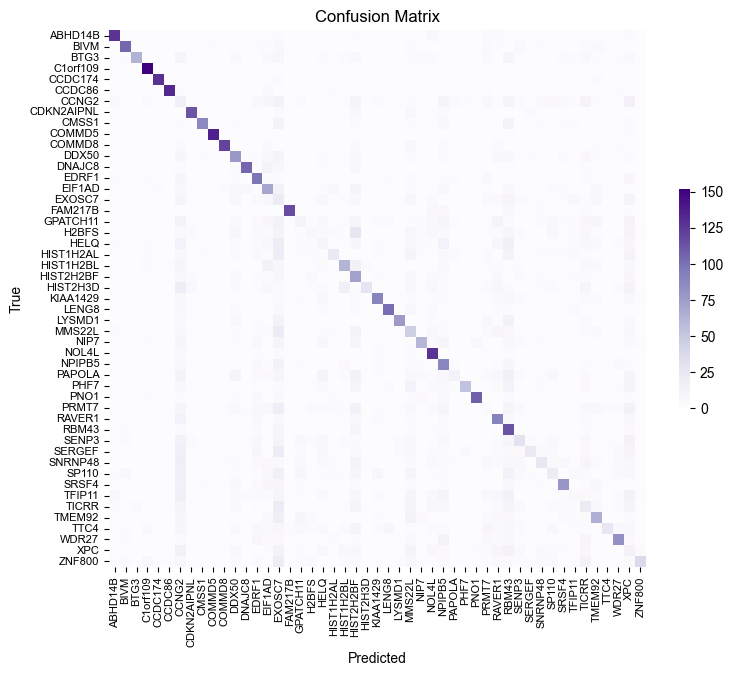

In [39]:
ad = sc.read_h5ad(f'{output_dir}/anndata/sim_ad_{data_version}_safe_c1.h5ad')
ad = ad[~ad.obs['perturbation'].isin(['control', 'neg'])].copy()
proba = ad.obsm['proba']
logit = proba.transform(lambda x: np.log((x + 1e-8) / (1 - x + 1e-8)))
p2i = {p: i for i, p in enumerate(proba.columns)}
i2p = {i: p for p, i in p2i.items()}
obs_df = ad.obs.copy()
pertidx = np.array([p2i[p] for p in obs_df['perturbation']])
obs_df['pert.proba'] = proba.values[np.arange(len(obs_df)), pertidx]
obs_df['pert.logit'] = logit.values[np.arange(len(obs_df)), pertidx]
obs_df['perturbation_pred'] = [i2p[i] for i in proba.values.argmax(axis=1)]
prepertidx = np.array([p2i[p] for p in obs_df['perturbation_pred']])
obs_df['pert.proba_pred'] = proba.values[np.arange(len(obs_df)), prepertidx]
obs_df['pert.logit_pred'] = logit.values[np.arange(len(obs_df)), prepertidx]

cfm = pd.crosstab(obs_df['perturbation'], obs_df['perturbation_pred'])
cfm = cfm.loc[sorted(cfm.index), sorted(cfm.columns)]

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(cfm, cmap='Purples', square=True, ax=ax, cbar_kws={'shrink': 0.3})
ax.set_xticks(np.arange(len(cfm.columns)) + 0.5, cfm.columns, fontsize=8)
ax.set_yticks(np.arange(len(cfm.index)) + 0.5, cfm.index, fontsize=8)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('../figures/5_simulation_cfm.pdf', bbox_inches='tight')
plt.show()


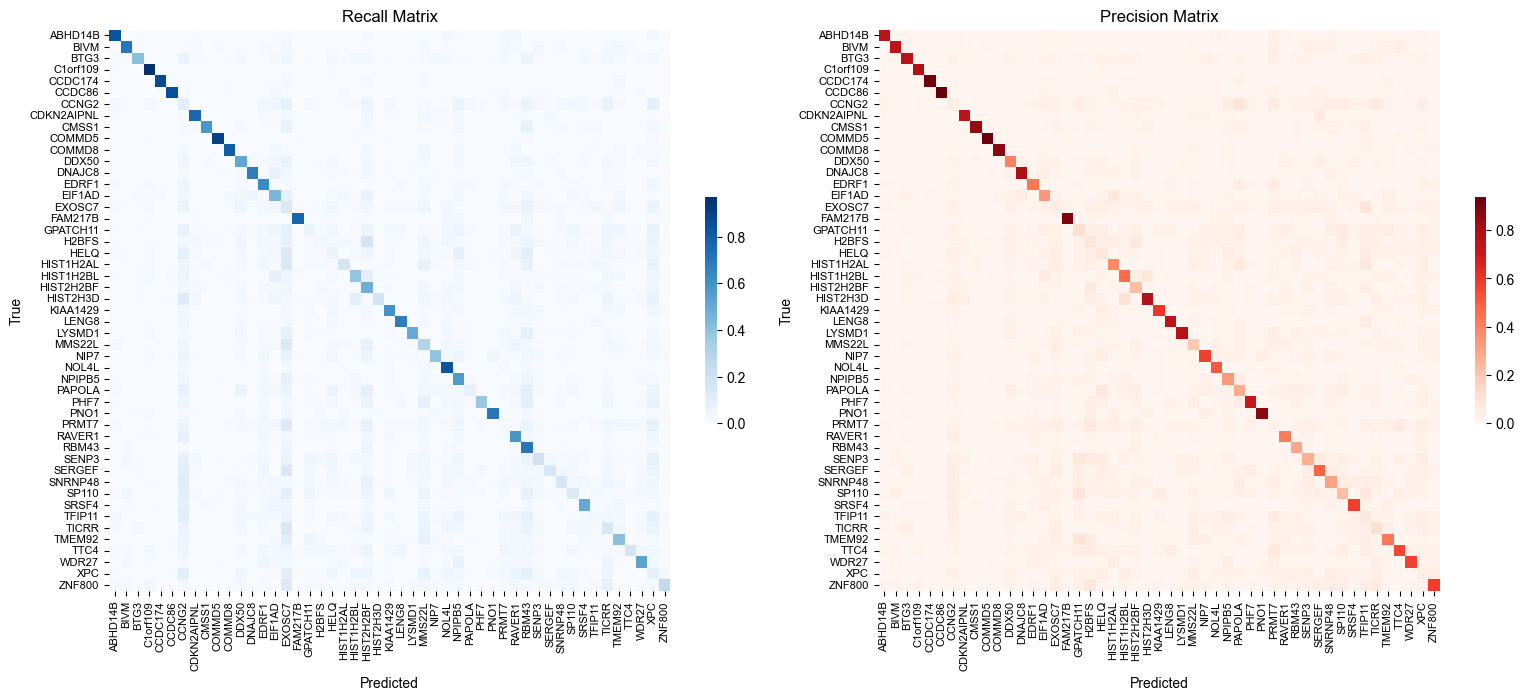

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sns.heatmap(
    cfm.transform(lambda x: x / x.sum(), axis=1), 
    cmap='Blues', 
    square=True, 
    ax=axes[0], 
    cbar_kws={'shrink': 0.3}
)
axes[0].set_xticks(np.arange(len(cfm.columns)) + 0.5, cfm.columns, fontsize=8)
axes[0].set_yticks(np.arange(len(cfm.index)) + 0.5, cfm.index, fontsize=8)
axes[0].set_title('Recall Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(
    cfm.transform(lambda x: x / x.sum(), axis=0), 
    cmap='Reds', 
    square=True, 
    ax=axes[1], 
    cbar_kws={'shrink': 0.3}
)
axes[1].set_xticks(np.arange(len(cfm.columns)) + 0.5, cfm.columns, fontsize=8)
axes[1].set_yticks(np.arange(len(cfm.index)) + 0.5, cfm.index, fontsize=8)
axes[1].set_title('Precision Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.tight_layout()
plt.savefig('../figures/5_simulation_precision_recall_matrix.pdf', bbox_inches='tight')
plt.show()

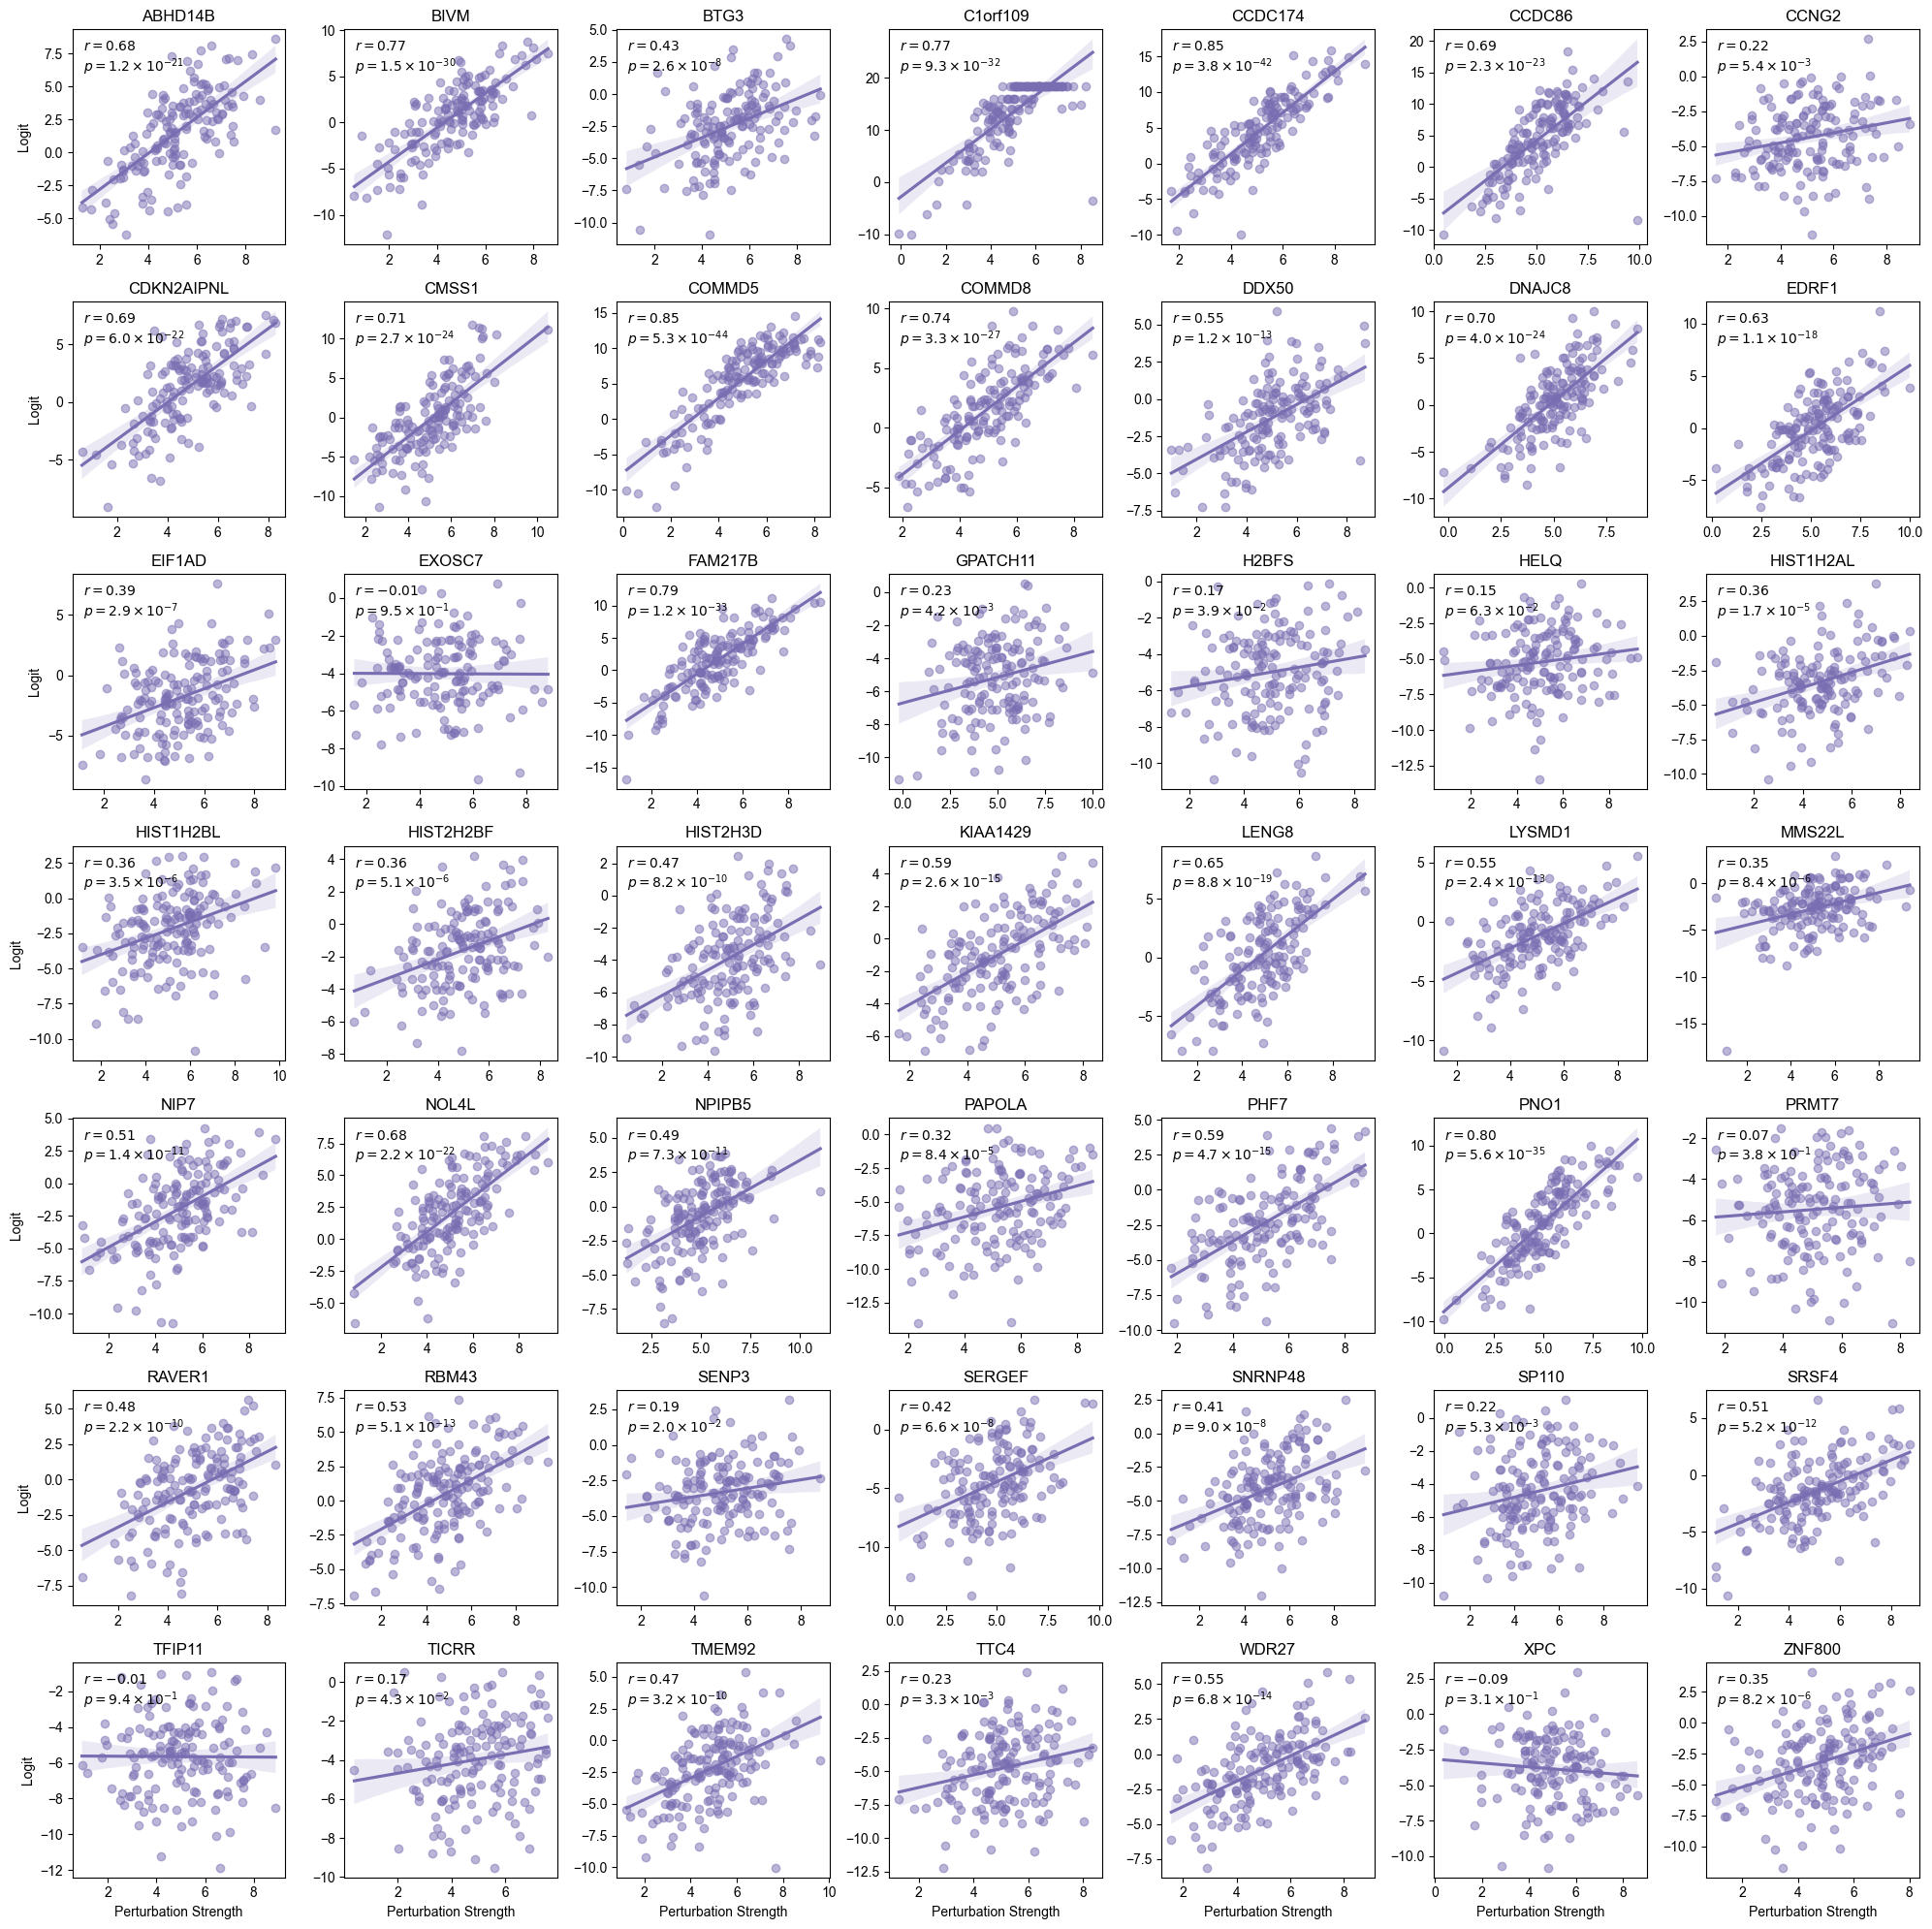

In [52]:
pert_list = np.random.choice(obs_df['perturbation'].unique(), size=49, replace=False)
pert_list = sorted(pert_list)
fig, axes = plt.subplots(7, 7, figsize=(20, 20))
for i, pert in enumerate(pert_list):
    plot_df = obs_df.query('perturbation == @pert')
    r, p = stats.pearsonr(plot_df['perturbation_strength'], plot_df['pert.logit'])
    # format p
    ptext = re.sub(r'e-0*', r'\\times 10^{-', f'{p:.1e}') + '}'    
    sns.regplot(
        data=plot_df, 
        x='perturbation_strength', y='pert.logit', 
        scatter=True,
        scatter_kws={'alpha': 0.5}, 
        ax=axes[i//7, i%7],
        color=sns.color_palette('Purples', 2)[-1],
    )
    axes[i//7, i%7].text(0.05, 0.95, f'$r={r:.2f}$\n$p={ptext}$', transform=axes[i//7, i%7].transAxes, fontsize=10, ha='left', va='top')
    axes[i//7, i%7].set_title(f'{pert}')
    if i // 7 != 6:
        axes[i//7, i%7].set_xlabel('')
    else:
        axes[i//7, i%7].set_xlabel('Perturbation Strength')
    if i % 7 != 0:
        axes[i//7, i%7].set_ylabel('')
    else:
        axes[i//7, i%7].set_ylabel('Logit')
plt.tight_layout()
plt.savefig('../figures/5_simulation_pert_strength_logit.pdf', bbox_inches='tight')
plt.show()
# %%


In [55]:
ad.var['L_norm'] = np.linalg.norm(ad.varm['L_hat'], axis=1, ord=2)
ad.var['L_max'] = np.linalg.norm(ad.varm['L_hat'], axis=1, ord=np.inf)
var_pert_df = ad.var.loc[pert_list].copy()
cfm = cfm.loc[var_pert_df.index, var_pert_df.index]
var_pert_df['Accuracy'] = cfm.map(lambda x: x / cfm.sum().sum()).values[np.arange(len(var_pert_df)), np.arange(len(var_pert_df))]
var_pert_df['Recall'] = cfm.transform(lambda x: x / x.sum(), axis=0).values[np.arange(len(var_pert_df)), np.arange(len(var_pert_df))]
var_pert_df['Precision'] = cfm.transform(lambda x: x / x.sum(), axis=1).values[np.arange(len(var_pert_df)), np.arange(len(var_pert_df))]

In [56]:
plot_df = (
    var_pert_df[['L_norm', 'L_max', 'Recall', 'Precision']]
    .melt(
        id_vars=['L_norm', 'L_max'], 
        value_vars=['Recall', 'Precision'],
        var_name='metric',
        value_name='value'
    )
)
plot_df.head()

,L_norm,L_max,metric,value
0,1.382368,0.398315,Recall,0.760479
1,1.518008,0.687210,Recall,0.750000
2,1.120801,0.369584,Recall,0.759036
3,2.090857,1.750691,Recall,0.787565
4,1.815598,1.242228,Recall,0.920863


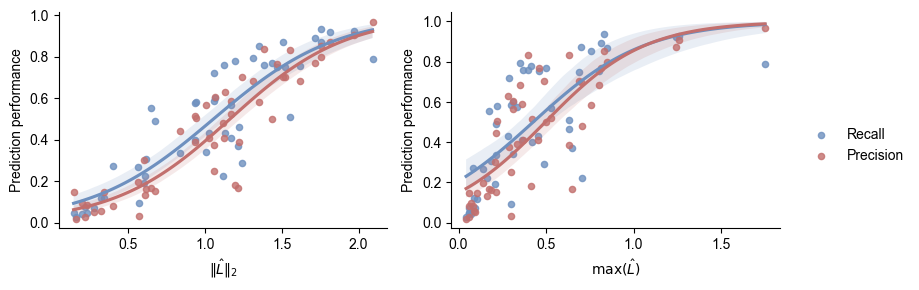

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharex=False, sharey=False)

# Plot Recall and Precision for L_norm
sns.regplot(
    data=var_pert_df,
    x='L_norm', y='Recall',
    scatter_kws={'s': 20},
    color=sns.color_palette('vlag')[0],
    logistic=True,
    label='Recall',
    ax=axes[0]
)
sns.regplot(
    data=var_pert_df,
    x='L_norm', y='Precision',
    scatter_kws={'s': 20},
    color=sns.color_palette('vlag')[-1],
    logistic=True,
    label='Precision',
    ax=axes[0]
)
axes[0].set_xlabel(r'$\|\hat{L}\|_2$')
axes[0].set_ylabel('Prediction performance')
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Plot Recall and Precision for L_max
sns.regplot(
    data=var_pert_df,
    x='L_max', y='Recall',
    scatter_kws={'s': 20},
    color=sns.color_palette('vlag')[0],
    logistic=True,
    label='Recall',
    ax=axes[1]
)
sns.regplot(
    data=var_pert_df,
    x='L_max', y='Precision',
    scatter_kws={'s': 20},
    color=sns.color_palette('vlag')[-1],
    logistic=True,
    label='Precision',
    ax=axes[1]
)
axes[1].set_xlabel(r'$\max(\hat{L})$')
axes[1].set_ylabel('Prediction performance')
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

# Create a single legend for both subplots and place it outside the axes
handles, labels = axes[0].get_legend_handles_labels()
# Only add legend to one axes, removing it from both subplots first
axes[0].legend_.remove() if axes[0].get_legend() else None
axes[1].legend_.remove() if axes[1].get_legend() else None

fig.legend(
    handles, labels, frameon=False,
    loc='center left', bbox_to_anchor=(1.0, 0.5), title=''
)

# plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.tight_layout()
plt.savefig('../figures/5_simulation_pertnorm_recall_precision.pdf', bbox_inches='tight')
plt.show()


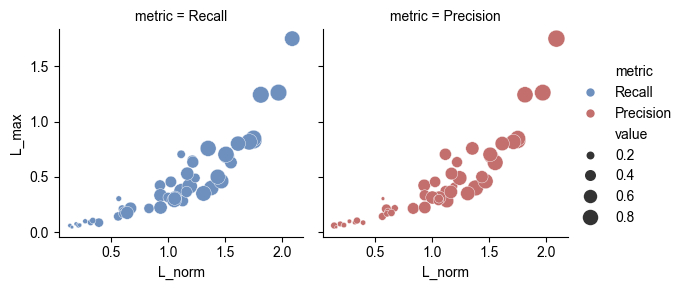

In [80]:
sns.relplot(
    kind='scatter',
    data=plot_df,
    x='L_norm', y='L_max',
    hue='metric',
    size='value',
    palette=[sns.color_palette('vlag')[0], sns.color_palette('vlag')[-1]],
    col='metric',
    sizes=(5, 150),
    height=3,
    aspect=1,
)